## Импорт библиотек и настройка воспроизводимости

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
import copy

# Для воспроизводимости
tf.random.set_seed(42)
np.random.seed(42)

## Загрузка и подготовка данных

1. Загрузка MNIST (рукописные цифры) и Fashion-MNIST (изображения одежды)
2. Нормализация пикселей: `x = x.astype('float32') / 255.0` (приведение к диапазону [0, 1])
3. Преобразование 2D-изображений 28×28 в 1D-векторы длины 784 (для полносвязной сети)
4. One-hot кодирование меток: 10 классов → вектор длины 10

In [2]:
# Загрузка MNIST (цифры)
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Загрузка Fashion-MNIST (одежда)
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = fashion_mnist.load_data()

# Нормализация [0,1]
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0
x_train_fashion = x_train_fashion.astype('float32') / 255.0
x_test_fashion = x_test_fashion.astype('float32') / 255.0

# Преобразование в вектор (28x28 -> 784) для полносвязной сети
x_train_mnist = x_train_mnist.reshape(-1, 784)
x_test_mnist = x_test_mnist.reshape(-1, 784)
x_train_fashion = x_train_fashion.reshape(-1, 784)
x_test_fashion = x_test_fashion.reshape(-1, 784)

# One-hot encoding для меток
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)
y_train_fashion = to_categorical(y_train_fashion, 10)
y_test_fashion = to_categorical(y_test_fashion, 10)

print("MNIST train:", x_train_mnist.shape, "test:", x_test_mnist.shape)
print("Fashion-MNIST train:", x_train_fashion.shape, "test:", x_test_fashion.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST train: (60000, 784) test: (10000, 784)
Fashion-MNIST train: (60000, 784) test: (10000, 784)


## Создание модели

**Архитектура сети:**
- Входной слой: 784 нейрона
- Скрытый слой 1: 256 нейронов, активация ReLU
- Скрытый слой 2: 128 нейронов, активация ReLU
- Выходной слой: 10 нейронов, активация Softmax

**Компиляция:**
- Оптимизатор: Adam, learning rate = 0.001
- Функция потерь: categorical_crossentropy
- Метрика: accuracy

In [3]:
def create_model():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(784,)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Проверка
model = create_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение на MNIST (первая задача)

**Параметры обучения:**
- batch size = 64
- эпохи = 15
- валидация на тестовой выборке

**Что сохраняем:**
- `theta_star` — веса модели после обучения на MNIST (опорные веса для EWC)

In [4]:
# Создаём и обучаем модель на MNIST
model_mnist = create_model()

history_mnist = model_mnist.fit(
    x_train_mnist, y_train_mnist,
    batch_size=64,
    epochs=15,
    validation_data=(x_test_mnist, y_test_mnist),
    verbose=1
)

# Сохраняем веса после обучения на MNIST
theta_star = model_mnist.get_weights()

# Оценка на тесте MNIST
test_loss, test_acc = model_mnist.evaluate(x_test_mnist, y_test_mnist, verbose=0)
print(f"Точность на MNIST после обучения: {test_acc:.4f} ({test_acc*100:.1f}%)")

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9337 - loss: 0.2307 - val_accuracy: 0.9669 - val_loss: 0.1103
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9728 - loss: 0.0914 - val_accuracy: 0.9720 - val_loss: 0.0896
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9822 - loss: 0.0589 - val_accuracy: 0.9742 - val_loss: 0.0787
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9881 - loss: 0.0397 - val_accuracy: 0.9756 - val_loss: 0.0852
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9899 - loss: 0.0314 - val_accuracy: 0.9726 - val_loss: 0.0935
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9920 - loss: 0.0238 - val_accuracy: 0.9763 - val_loss: 0.0858
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9923 - loss: 0.0227 - val_accuracy: 0.9779 - val_loss: 0.0859
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9946 - loss: 0.0164 - val_accuracy: 0.

## Вычисление матрицы Фишера

**Формула:**
$$F_i = \mathbb{E}\left[\left(\frac{\partial L}{\partial \theta_i}\right)^2\right]$$

**Алгоритм:**
1. Берём 2000 случайных примеров из MNIST
2. Для каждого примера вычисляем градиент функции потерь по каждому весу
3. Возводим градиент в квадрат
4. Усредняем по всем примерам

**Результат:** `fisher` — список важностей весов. Чем больше значение, тем важнее вес для распознавания цифр.

**Назначение:** Оценка важности весов для EWC — веса с высоким $F_i$ будут сильнее штрафоваться при обучении на новой задаче.

In [5]:
# Вычисляет диагональ матрицы Фишера по переданной выборке

def compute_fisher(model, x_sample, y_sample):
    # Инициализируем список для хранения накопленных квадратов градиентов
    fisher = [tf.zeros_like(var) for var in model.trainable_variables]

    batch_size = 64
    n_samples = len(x_sample)

    for i in range(0, n_samples, batch_size):
        x_batch = x_sample[i:i+batch_size]
        y_batch = y_sample[i:i+batch_size]

        with tf.GradientTape() as tape:
            predictions = model(x_batch, training=True)
            loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_batch, predictions))

        # Получаем градиенты
        grads = tape.gradient(loss, model.trainable_variables)

        # Добавляем квадраты градиентов
        for j, grad in enumerate(grads):
            if grad is not None:
                fisher[j] += tf.square(grad)

    # Усредняем
    for j in range(len(fisher)):
        fisher[j] = fisher[j] / n_samples

    return fisher

# Берём часть тренировочных данных MNIST для оценки Фишера (2000 примеров)
n_fisher_samples = 2000
indices = np.random.choice(len(x_train_mnist), n_fisher_samples, replace=False)
x_fisher = x_train_mnist[indices]
y_fisher = y_train_mnist[indices]

fisher = compute_fisher(model_mnist, x_fisher, y_fisher)

print("Матрица Фишера вычислена. Размерности:")
for i, f in enumerate(fisher):
    print(f"  Параметр {i}: {f.shape}, сумма элементов = {tf.reduce_sum(tf.abs(f)).numpy():.6f}")

Матрица Фишера вычислена. Размерности:
  Параметр 0: (784, 256), сумма элементов = 0.003372
  Параметр 1: (256,), сумма элементов = 0.000039
  Параметр 2: (256, 128), сумма элементов = 0.000845
  Параметр 3: (128,), сумма элементов = 0.000006
  Параметр 4: (128, 10), сумма элементов = 0.001030
  Параметр 5: (10,), сумма элементов = 0.000002


## Базовый эксперимент (без EWC)

Демонстрация катастрофического забывания без защиты.

1. Создаём новую модель
2. Загружаем веса `theta_star` (обученные на MNIST)
3. Обучаем модель на Fashion-MNIST (15 эпох)
4. Доступ к MNIST на этом этапе отсутствует


In [6]:
# Берём модель, обученную на MNIST
model_no_ewc = create_model()
model_no_ewc.set_weights(theta_star)  # начинаем с сохранённых весов

# Будем записывать точность на MNIST в процессе обучения на Fashion
mnist_acc_history_no_ewc = []

# Обучаем на Fashion-MNIST
history_no_ewc = model_no_ewc.fit(
    x_train_fashion, y_train_fashion,
    batch_size=64,
    epochs=15,
    validation_data=(x_test_fashion, y_test_fashion),
    verbose=1,
    callbacks=[
        tf.keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs: mnist_acc_history_no_ewc.append(
                model_no_ewc.evaluate(x_test_mnist, y_test_mnist, verbose=0)[1]
            )
        )
    ]
)

# Оценка после обучения
test_acc_mnist_no_ewc = model_no_ewc.evaluate(x_test_mnist, y_test_mnist, verbose=0)[1]
test_acc_fashion_no_ewc = model_no_ewc.evaluate(x_test_fashion, y_test_fashion, verbose=0)[1]

print(f"\n=== Без EWC ===")
print(f"Точность на MNIST после обучения на Fashion: {test_acc_mnist_no_ewc:.4f} ({test_acc_mnist_no_ewc*100:.1f}%)")
print(f"Точность на Fashion: {test_acc_fashion_no_ewc:.4f} ({test_acc_fashion_no_ewc*100:.1f}%)")

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8007 - loss: 0.6726 - val_accuracy: 0.8483 - val_loss: 0.4347
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8671 - loss: 0.3702 - val_accuracy: 0.8580 - val_loss: 0.3950
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8814 - loss: 0.3244 - val_accuracy: 0.8665 - val_loss: 0.3750
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8911 - loss: 0.2968 - val_accuracy: 0.8700 - val_loss: 0.3614
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8979 - loss: 0.2758 - val_accuracy: 0.8754 - val_loss: 0.3525
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9039 - loss: 0.2585 - val_accuracy: 0.8746 - val_loss: 0.3493
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9085 - loss: 0.2450 - val_accuracy: 0.8803 - val_loss: 0.3493
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9139 - loss: 0.2314 - val_accuracy: 0.

## Эксперимент с EWC

**Функция потерь EWC:**
$$L(\theta) = L_{\text{fashion}}(\theta) + \frac{\lambda}{2} \sum_i F_i (\theta_i - \theta^*_i)^2$$

**Где:**
- $L_{\text{fashion}}$ — стандартная кросс-энтропия на Fashion-MNIST
- $F_i$ — важность i-го веса
- $\theta^*_i$ — сохранённые веса после MNIST
- $\lambda$ — гиперпараметр (подобран = 35000)

**Процесс:**
1. Создаём модель с обёрткой `EWCModel`
2. Загружаем веса `theta_star`
3. Обучаем на Fashion-MNIST с λ = 35000

In [7]:
class EWCModel(tf.keras.Model):
    def __init__(self, model, fisher, theta_star, lambda_val):
        super(EWCModel, self).__init__()
        self.model = model
        self.fisher = fisher
        self.theta_star = theta_star
        self.lambda_val = lambda_val
        self.loss_tracker = tf.keras.metrics.Mean(name='loss')
        self.acc_tracker = tf.keras.metrics.CategoricalAccuracy(name='accuracy')

    def call(self, inputs, training=False):
        return self.model(inputs, training=training)

    def train_step(self, data):
        x, y = data

        with tf.GradientTape() as tape:
            predictions = self(x, training=True)
            ce_loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y, predictions))

            # EWC штраф
            ewc_penalty = 0
            for i, theta in enumerate(self.model.trainable_variables):
                diff = theta - self.theta_star[i]
                ewc_penalty += tf.reduce_sum(self.fisher[i] * tf.square(diff))
            ewc_penalty = ewc_penalty * (self.lambda_val / 2.0)

            total_loss = ce_loss + ewc_penalty

        grads = tape.gradient(total_loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        # Обновляем метрики
        self.loss_tracker.update_state(total_loss)
        self.acc_tracker.update_state(y, predictions)

        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_tracker.result()
        }

    def test_step(self, data):
        x, y = data
        predictions = self(x, training=False)
        loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y, predictions))

        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(y, predictions)

        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_tracker.result()
        }

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]

# Создаём модель с EWC
model_ewc = create_model()
model_ewc.set_weights(theta_star)

# Оборачиваем для кастомной функции потерь
ewc_wrapper = EWCModel(model_ewc, fisher, theta_star, lambda_val=35000)
ewc_wrapper.compile(optimizer=Adam(learning_rate=0.001))

# Точность на MNIST
mnist_acc_history_ewc = []

# Обучаем
history_ewc = ewc_wrapper.fit(
    x_train_fashion, y_train_fashion,
    batch_size=64,
    epochs=15,
    validation_data=(x_test_fashion, y_test_fashion),
    verbose=1,
    callbacks=[
        tf.keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs: mnist_acc_history_ewc.append(
                model_ewc.evaluate(x_test_mnist, y_test_mnist, verbose=0)[1]
            )
        )
    ]
)

# Оценка после обучения
test_acc_mnist_ewc = model_ewc.evaluate(x_test_mnist, y_test_mnist, verbose=0)[1]
test_acc_fashion_ewc = model_ewc.evaluate(x_test_fashion, y_test_fashion, verbose=0)[1]

print(f"\n=== С EWC (λ=35000) ===")
print(f"Точность на MNIST после обучения на Fashion: {test_acc_mnist_ewc:.4f} ({test_acc_mnist_ewc*100:.1f}%)")
print(f"Точность на Fashion: {test_acc_fashion_ewc:.4f} ({test_acc_fashion_ewc*100:.1f}%)")

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8005 - loss: 0.6940 - val_accuracy: 0.8466 - val_loss: 0.4357
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8649 - loss: 0.3914 - val_accuracy: 0.8600 - val_loss: 0.3924
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8787 - loss: 0.3478 - val_accuracy: 0.8656 - val_loss: 0.3720
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8863 - loss: 0.3208 - val_accuracy: 0.8750 - val_loss: 0.3596
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8940 - loss: 0.3016 - val_accuracy: 0.8807 - val_loss: 0.3448
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8996 - loss: 0.2863 - val_accuracy: 0.8813 - val_loss: 0.3466
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9042 - loss: 0.2725 - val_accuracy: 0.8821 - val_loss: 0.3471
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9084 - loss: 0.2622 - val_accuracy: 0.

## Итоговая таблица результатов

In [10]:
from IPython.display import display, HTML

initial_acc = "97.78%"

data = [
    ["Без EWC", initial_acc, f"{test_acc_mnist_no_ewc*100:.1f}%", f"{test_acc_fashion_no_ewc*100:.1f}%"],
    ["С EWC (λ=5000)", initial_acc, f"{test_acc_mnist_ewc*100:.1f}%", f"{test_acc_fashion_ewc*100:.1f}%"]
]

html = "<table border='1' cellpadding='8' style='border-collapse: collapse;'>"
html += "<tr><th>Метод</th><th>Точность на MNIST (до)</th><th>Точность на MNIST (после)</th><th>Точность на Fashion-MNIST</th></tr>"
for row in data:
    html += "<tr>"
    for cell in row:
        html += f"<td>{cell}</td>"
    html += "</tr>"
html += "</table>"

display(HTML(html))

Метод,Точность на MNIST (до),Точность на MNIST (после),Точность на Fashion-MNIST
Без EWC,97.78%,31.2%,88.0%
С EWC (λ=5000),97.78%,76.0%,88.1%


## График динамики забывания

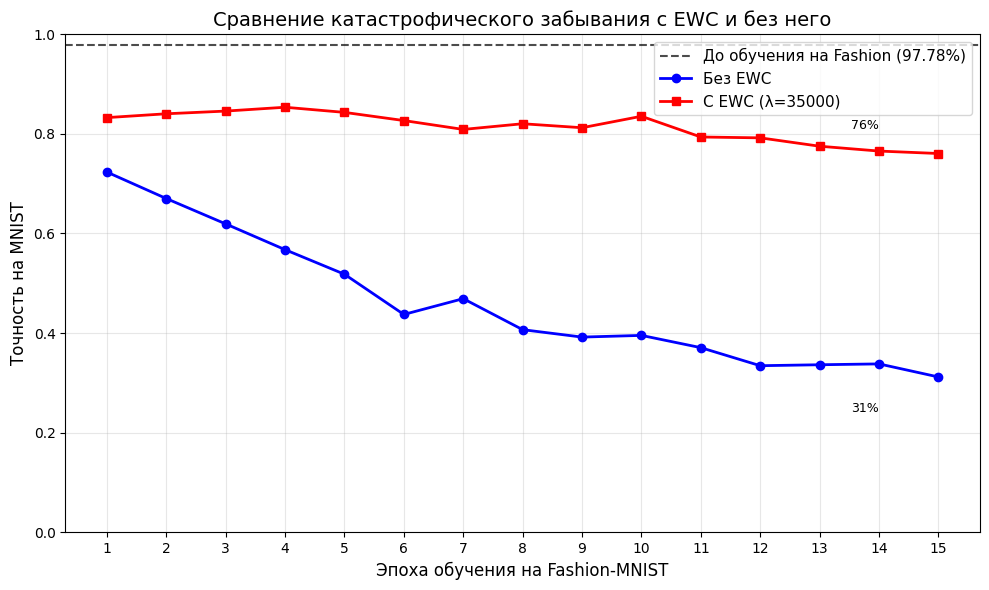

In [14]:
plt.figure(figsize=(10, 6))

# Горизонтальная линия — начальная точность 97.78%
plt.axhline(y=97.78/100, color='black', linestyle='--', linewidth=1.5, label='До обучения на Fashion (97.78%)', alpha=0.7)

# Линии с точками по эпохам (15 эпох)
plt.plot(range(1, 16), mnist_acc_history_no_ewc, 'b-o', label='Без EWC', linewidth=2, markersize=6, markevery=1)
plt.plot(range(1, 16), mnist_acc_history_ewc, 'r-s', label='С EWC (λ=35000)', linewidth=2, markersize=6, markevery=1)

plt.xlabel('Эпоха обучения на Fashion-MNIST', fontsize=12)
plt.ylabel('Точность на MNIST', fontsize=12)
plt.title('Сравнение катастрофического забывания с EWC и без него', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.xticks(range(1, 16))

# Подписи финальных точек
plt.annotate(f'{int(mnist_acc_history_no_ewc[-1]*100)}%',
             xy=(15, mnist_acc_history_no_ewc[-1]),
             xytext=(14, mnist_acc_history_no_ewc[-1]-0.07),
             fontsize=9, ha='right')
plt.annotate(f'{int(mnist_acc_history_ewc[-1]*100)}%',
             xy=(15, mnist_acc_history_ewc[-1]),
             xytext=(14, mnist_acc_history_ewc[-1]+0.05),
             fontsize=9, ha='right')

plt.tight_layout()
plt.savefig('ewc_comparison.png', dpi=200)
plt.show()

## Подбор оптимального гиперпараметра λ

**Перебираемые значения:** 0, 500, 1000, 2000, 5000, 8000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 50000

1. Создаём новую модель, загружаем `theta_star`
2. Обучаем на Fashion-MNIST с EWC (15 эпох)
3. Измеряем точность на MNIST и Fashion-MNIST

In [12]:
# Список λ для тестирования
lambda_tests = [0, 500, 1000, 2000, 5000, 8000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 50000]
results_lambda = []  # (λ, acc_mnist, acc_fashion)

# Количество эпох для дообучения на Fashion
epochs_fashion = 15

print("Начинаем подбор λ...")
print("=" * 60)

for lam in lambda_tests:
    print(f"\nТестируем λ = {lam}")

    # Создаём новую модель и загружаем веса после MNIST
    model_test = create_model()
    model_test.set_weights(theta_star)

    # Оборачиваем в EWC
    wrapper = EWCModel(model_test, fisher, theta_star, lambda_val=lam)
    wrapper.compile(optimizer=Adam(learning_rate=0.001))

    # Обучаем на Fashion-MNIST
    wrapper.fit(
        x_train_fashion, y_train_fashion,
        batch_size=64,
        epochs=epochs_fashion,
        validation_data=(x_test_fashion, y_test_fashion),
        verbose=0
    )

    # Оцениваем точность
    acc_mnist = model_test.evaluate(x_test_mnist, y_test_mnist, verbose=0)[1]
    acc_fashion = model_test.evaluate(x_test_fashion, y_test_fashion, verbose=0)[1]

    results_lambda.append((lam, acc_mnist, acc_fashion))
    print(f"  MNIST: {acc_mnist*100:.1f}%, Fashion: {acc_fashion*100:.1f}%")

Начинаем подбор λ...

Тестируем λ = 0
  MNIST: 34.6%, Fashion: 88.0%

Тестируем λ = 500
  MNIST: 46.4%, Fashion: 88.3%

Тестируем λ = 1000
  MNIST: 44.9%, Fashion: 88.3%

Тестируем λ = 2000
  MNIST: 50.4%, Fashion: 88.1%

Тестируем λ = 5000
  MNIST: 56.4%, Fashion: 88.4%

Тестируем λ = 8000
  MNIST: 64.7%, Fashion: 88.1%

Тестируем λ = 10000
  MNIST: 67.2%, Fashion: 88.1%

Тестируем λ = 15000
  MNIST: 69.2%, Fashion: 87.9%

Тестируем λ = 20000
  MNIST: 70.2%, Fashion: 88.1%

Тестируем λ = 25000
  MNIST: 72.4%, Fashion: 88.0%

Тестируем λ = 30000
  MNIST: 74.6%, Fashion: 88.6%

Тестируем λ = 35000
  MNIST: 76.0%, Fashion: 88.1%

Тестируем λ = 40000
  MNIST: 71.9%, Fashion: 88.3%

Тестируем λ = 50000
  MNIST: 74.7%, Fashion: 87.9%


## График влияния λ и вывод оптимального значения

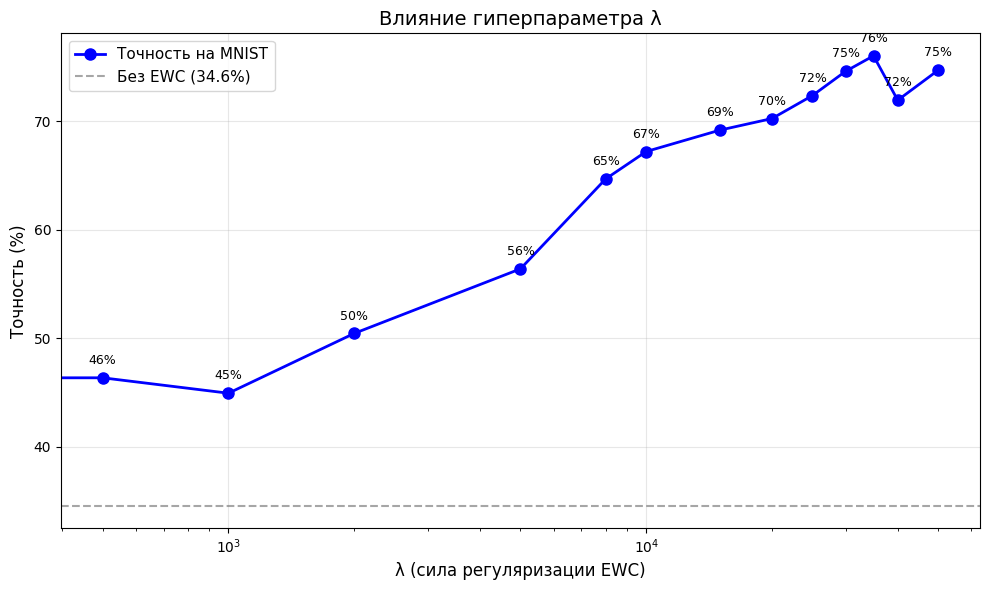


Оптимальное λ: 35000
Максимальная точность на MNIST: 76.0%


In [13]:
plt.figure(figsize=(10, 6))

lams = [r[0] for r in results_lambda]
mnist_accs = [r[1] * 100 for r in results_lambda]

# Основная линия — точность на MNIST
plt.plot(lams, mnist_accs, 'b-o', linewidth=2, markersize=8, label='Точность на MNIST')

# Горизонтальная линия — базовый уровень без EWC (λ=0)
plt.axhline(y=mnist_accs[0], color='gray', linestyle='--', alpha=0.7, label=f'Без EWC ({mnist_accs[0]:.1f}%)')

plt.xlabel('λ (сила регуляризации EWC)', fontsize=12)
plt.ylabel('Точность (%)', fontsize=12)
plt.title('Влияние гиперпараметра λ', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xscale('log')  # логарифмическая шкала

# Подписываем точки
for i, lam in enumerate(lams):
    plt.annotate(f'{mnist_accs[i]:.0f}%', (lam, mnist_accs[i]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('lambda_influence_mnist.png', dpi=200, bbox_inches='tight')
plt.show()

# Вывод оптимального λ
best_idx = max(range(len(mnist_accs)), key=lambda i: mnist_accs[i])
print(f"\nОптимальное λ: {lams[best_idx]}")
print(f"Максимальная точность на MNIST: {mnist_accs[best_idx]:.1f}%")